# CropGuard AI — EfficientNetV2B0 Transfer Learning

This notebook trains the main transfer learning model for CropGuard AI.

Model:
- EfficientNetV2B0 pretrained on ImageNet
- Fine-tuned for 38 plant disease classes

Purpose:
- Train stronger model than Custom CNN baseline
- Save best model
- Save training curves
- Save classification report
- Save confusion matrix
- Export outputs back to PyCharm project

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-23 16:26:16.816445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782231977.007190      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782231977.062335      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782231977.436794      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782231977.436830      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782231977.436832      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
from pathlib import Path
import json
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 5
TOTAL_EPOCHS = HEAD_EPOCHS + FINE_TUNE_EPOCHS

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

WORKING_DIR = Path("/kaggle/working")

MODELS_DIR = WORKING_DIR / "models"
OUTPUTS_DIR = WORKING_DIR / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
LOGS_DIR = OUTPUTS_DIR / "training_logs"
ERROR_DIR = OUTPUTS_DIR / "error_analysis"

for folder in [MODELS_DIR, OUTPUTS_DIR, METRICS_DIR, LOGS_DIR, ERROR_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORKING_DIR)

Working directory: /kaggle/working


In [4]:
from tensorflow.keras import mixed_precision

try:
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled:", e)

Mixed precision enabled: <DTypePolicy "mixed_float16">


In [5]:
def find_dataset_root():
    input_root = Path("/kaggle/input")

    for train_dir in input_root.rglob("train"):
        valid_dir = train_dir.parent / "valid"

        if valid_dir.exists():
            return train_dir.parent, train_dir, valid_dir

    raise FileNotFoundError(
        "Could not find train/valid folders. "
        "Make sure vipoooool/new-plant-diseases-dataset is added as Kaggle input."
    )


DATASET_ROOT, TRAIN_DIR, VALID_DIR = find_dataset_root()

print("Dataset root:", DATASET_ROOT)
print("Train dir:", TRAIN_DIR)
print("Valid dir:", VALID_DIR)

Dataset root: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Train dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
num_classes = len(class_names)

train_counts = {}
valid_counts = {}

for class_name in class_names:
    train_class_dir = TRAIN_DIR / class_name
    valid_class_dir = VALID_DIR / class_name

    train_counts[class_name] = len([
        p for p in train_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    valid_counts[class_name] = len([
        p for p in valid_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

train_total = sum(train_counts.values())
valid_total = sum(valid_counts.values())

print("Number of classes:", num_classes)
print("Total train images:", train_total)
print("Total valid images:", valid_total)

distribution_df = pd.DataFrame([
    {
        "class_name": class_name,
        "train_count": train_counts[class_name],
        "valid_count": valid_counts[class_name],
    }
    for class_name in class_names
])

distribution_df.to_csv(METRICS_DIR / "efficientnetv2b0_dataset_distribution.csv", index=False)
distribution_df.head()

Number of classes: 38
Total train images: 70295
Total valid images: 17572


,class_name,train_count,valid_count
0,Apple___Apple_scab,2016,504
1,Apple___Black_rot,1987,497
2,Apple___Cedar_apple_rust,1760,440
3,Apple___healthy,2008,502
4,Blueberry___healthy,1816,454


In [8]:
class_indices = {str(index): class_name for index, class_name in enumerate(class_names)}

with open(MODELS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_indices, f, indent=4)

class_weights = {}

for index, class_name in enumerate(class_names):
    class_count = train_counts[class_name]
    class_weights[index] = train_total / (num_classes * class_count)

with open(MODELS_DIR / "class_weights.json", "w", encoding="utf-8") as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=4)

print("Saved class_indices.json")
print("Saved class_weights.json")

Saved class_indices.json
Saved class_weights.json


In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_names=train_ds.class_names,
)

print("Classes loaded:", len(train_ds.class_names))
print(train_ds.class_names[:5])

Found 70295 files belonging to 38 classes.


I0000 00:00:1782232749.606467      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782232749.612568      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Classes loaded: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [10]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Min pixel: 0.0
Max pixel: 255.0


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

print("Datasets optimized.")

Datasets optimized.


In [12]:
def build_efficientnetv2b0(num_classes):
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)

    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        include_preprocessing=True,
    )

    base_model.trainable = False

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = tf.keras.layers.Dropout(0.35)(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="efficientnetv2b0_transfer")

    return model, base_model


model, base_model = build_efficientnetv2b0(num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
    ],
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetv2b0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c

 Total params: 5,967,990 (22.77 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [13]:
model_path = MODELS_DIR / "efficientnetv2b0_best.keras"
history_csv_path = LOGS_DIR / "efficientnetv2b0_history.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(
        filename=history_csv_path,
        append=False,
    ),
]

print("Model will be saved to:", model_path)

Model will be saved to: /kaggle/working/models/efficientnetv2b0_best.keras


In [14]:
history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/5


I0000 00:00:1782232843.941301     180 cuda_dnn.cc:529] Loaded cuDNN version 91002


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7526 - loss: 1.0732 - top_3_accuracy: 0.8787
Epoch 1: val_accuracy improved from None to 0.94599, saving model to /kaggle/working/models/efficientnetv2b0_best.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnetv2b0_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 201s 80ms/step - accuracy: 0.8570 - loss: 0.5924 - top_3_accuracy: 0.9539 - val_accuracy: 0.9460 - val_loss: 0.2135 - val_top_3_accuracy: 0.9916 - learning_rate: 0.0010
Epoch 2/5
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9248 - loss: 0.2637 - top_3_accuracy: 0.9882
Epoch 2: val_accuracy improved from 0.94599 to 0.95351, saving model to /kaggle/working/models/efficientnetv2b0_best.keras

Epoch 2: finished saving model to /kaggle/working/models/efficientnetv2b0_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 144s 65ms/step - accuracy: 0.9276 - loss: 0.2456 - top_3_accuracy: 0.9894 - val_accuracy: 0.9535 - val_loss: 0.1591 - val_top_3_accuracy: 

In [15]:
base_model.trainable = True

# Freeze most layers, fine-tune only the last part
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
    ],
)

print("Fine-tuning last 30 layers...")

Fine-tuning last 30 layers...


In [16]:
history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9062 - loss: 0.3047 - top_3_accuracy: 0.9808
Epoch 6: val_accuracy improved from 0.96785 to 0.96870, saving model to /kaggle/working/models/efficientnetv2b0_best.keras

Epoch 6: finished saving model to /kaggle/working/models/efficientnetv2b0_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 203s 83ms/step - accuracy: 0.9209 - loss: 0.2578 - top_3_accuracy: 0.9856 - val_accuracy: 0.9687 - val_loss: 0.1075 - val_top_3_accuracy: 0.9971 - learning_rate: 1.0000e-05
Epoch 7/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9423 - loss: 0.1931 - top_3_accuracy: 0.9919
Epoch 7: val_accuracy improved from 0.96870 to 0.97359, saving model to /kaggle/working/models/efficientnetv2b0_best.keras

Epoch 7: finished saving model to /kaggle/working/models/efficientnetv2b0_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 168s 76ms/step - accuracy: 0.9444 - loss: 0.1837 - top_3_accuracy: 0.9924 - val_accuracy: 0.9736 - val_loss: 0.0912 - v

In [17]:
best_model = tf.keras.models.load_model(model_path)

results = best_model.evaluate(valid_ds, return_dict=True)

print("Final EfficientNetV2B0 validation results:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.9796 - loss: 0.0675 - top_3_accuracy: 0.9987
Final EfficientNetV2B0 validation results:
accuracy: 0.9796
loss: 0.0675
top_3_accuracy: 0.9987


In [18]:
results_df = pd.DataFrame([
    {
        "model": "efficientnetv2b0",
        "accuracy": results["accuracy"],
        "loss": results["loss"],
        "top_3_accuracy": results["top_3_accuracy"],
        "head_epochs": HEAD_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "total_epochs": TOTAL_EPOCHS,
        "image_size": str(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "train_images": train_total,
        "valid_images": valid_total,
        "num_classes": num_classes,
    }
])

results_path = METRICS_DIR / "efficientnetv2b0_results.csv"
results_df.to_csv(results_path, index=False)

results_df

,model,accuracy,loss,top_3_accuracy,head_epochs,fine_tune_epochs,total_epochs,image_size,batch_size,train_images,valid_images,num_classes
0,efficientnetv2b0,0.97957,0.067477,0.998748,5,5,10,"(224, 224)",32,70295,17572,38


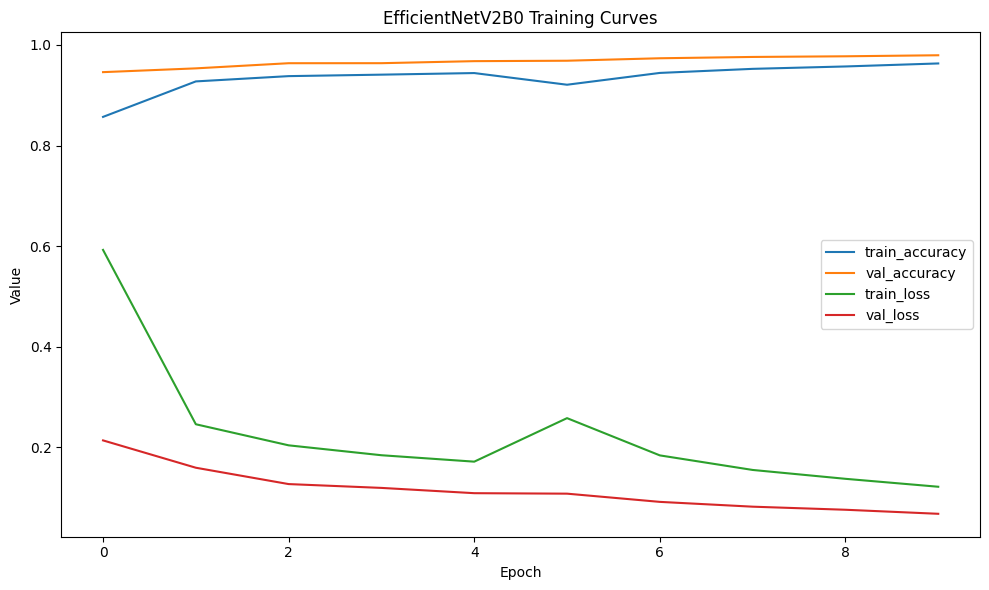

Saved: /kaggle/working/outputs/metrics/efficientnetv2b0_training_curves.png


In [19]:
head_df = pd.DataFrame(history_head.history)
fine_df = pd.DataFrame(history_fine.history)

history_df = pd.concat([head_df, fine_df], ignore_index=True)
history_df.to_csv(LOGS_DIR / "efficientnetv2b0_history_from_notebook.csv", index=False)

plt.figure(figsize=(10, 6))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("EfficientNetV2B0 Training Curves")
plt.legend()
plt.tight_layout()

curve_path = METRICS_DIR / "efficientnetv2b0_training_curves.png"
plt.savefig(curve_path, dpi=200)
plt.show()

print("Saved:", curve_path)

In [22]:
y_true = []
y_pred = []
y_prob = []

for images, labels in valid_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

y_true shape: (17572,)
y_pred shape: (17572,)
y_prob shape: (17572, 38)


In [23]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()

classification_report_path = METRICS_DIR / "efficientnetv2b0_classification_report.csv"
report_df.to_csv(classification_report_path)

report_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.989980,0.980159,0.985045,504.0
Apple___Black_rot,0.993964,0.993964,0.993964,497.0
Apple___Cedar_apple_rust,0.995444,0.993182,0.994312,440.0
Apple___healthy,0.980431,0.998008,0.989141,502.0
Blueberry___healthy,1.000000,0.995595,0.997792,454.0


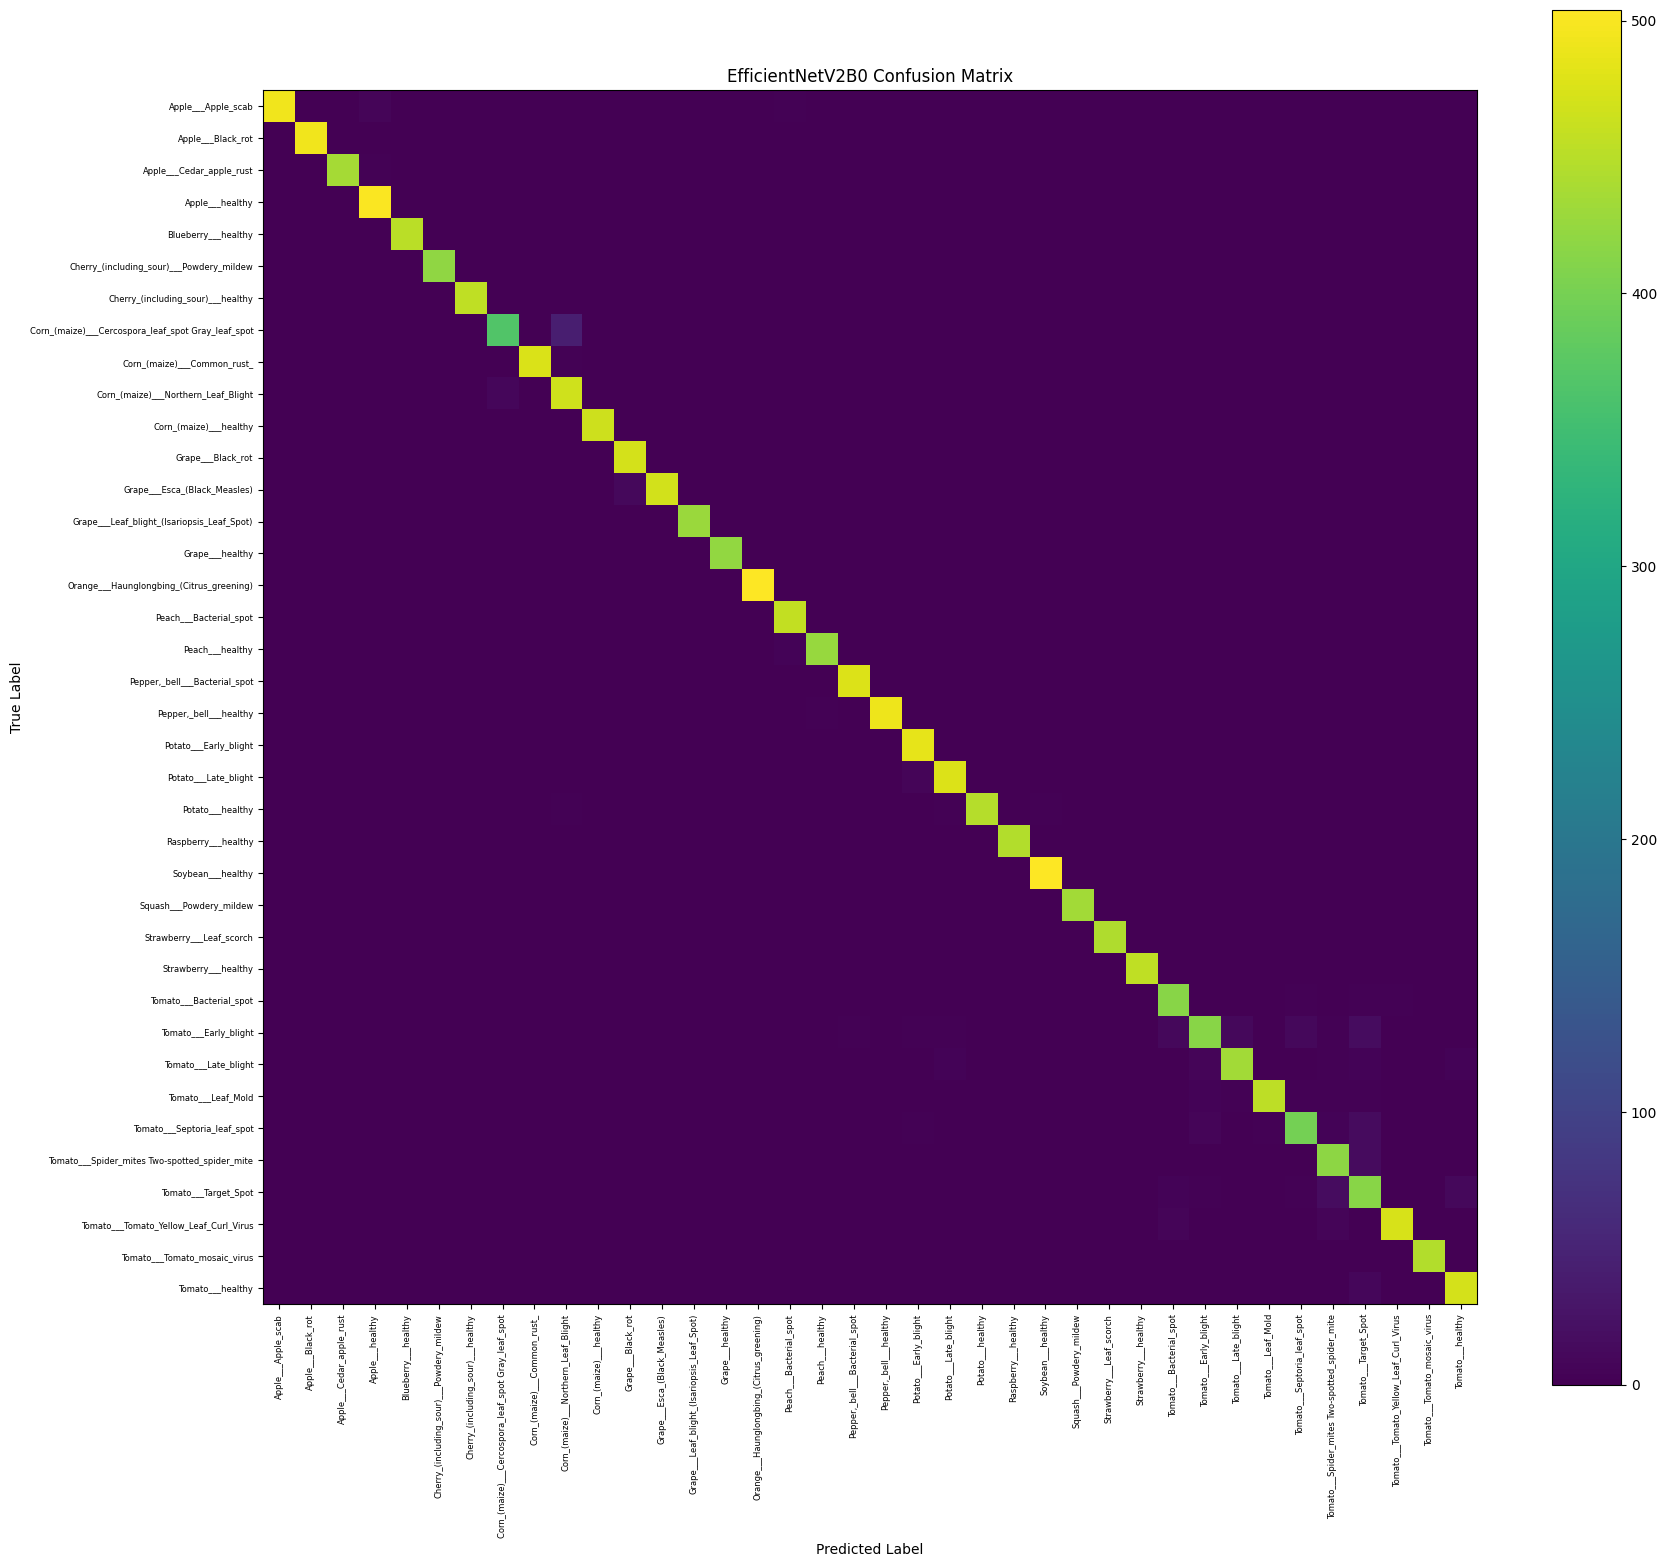

Saved: /kaggle/working/outputs/metrics/efficientnetv2b0_confusion_matrix.png


In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title("EfficientNetV2B0 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=6)
plt.yticks(tick_marks, class_names, fontsize=6)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = METRICS_DIR / "efficientnetv2b0_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=250)
plt.show()

print("Saved:", confusion_matrix_path)

In [25]:
wrong_indices = np.where(y_true != y_pred)[0]

error_summary = []

for idx in wrong_indices[:300]:
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = float(np.max(y_prob[idx]))

    error_summary.append({
        "true_class": true_label,
        "predicted_class": pred_label,
        "confidence": confidence,
    })

error_df = pd.DataFrame(error_summary)

error_path = ERROR_DIR / "efficientnetv2b0_wrong_predictions_summary.csv"
error_df.to_csv(error_path, index=False)

error_df.head(20)

,true_class,predicted_class,confidence
0,Apple___Apple_scab,"Pepper,_bell___Bacterial_spot",0.421924
1,Apple___Apple_scab,Apple___healthy,0.507090
2,Apple___Apple_scab,Apple___healthy,0.643929
3,Apple___Apple_scab,Apple___healthy,0.902777
4,Apple___Apple_scab,Peach___Bacterial_spot,0.602204
5,Apple___Apple_scab,Peach___Bacterial_spot,0.576696
6,Apple___Apple_scab,Apple___Black_rot,0.517294
7,Apple___Apple_scab,Apple___healthy,0.594561
8,Apple___Apple_scab,Apple___healthy,0.867016
9,Apple___Apple_scab,Apple___healthy,0.898965


In [26]:
model_metadata = {
    "project": "CropGuard AI",
    "model_name": "efficientnetv2b0_transfer",
    "dataset": "Kaggle New Plant Diseases Dataset",
    "num_classes": num_classes,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "head_epochs": HEAD_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "total_epochs": TOTAL_EPOCHS,
    "train_images": int(train_total),
    "valid_images": int(valid_total),
    "metrics": {
        "accuracy": float(results["accuracy"]),
        "loss": float(results["loss"]),
        "top_3_accuracy": float(results["top_3_accuracy"]),
    },
    "notes": [
        "EfficientNetV2B0 is the main transfer learning model.",
        "The pretrained base was frozen first, then partially fine-tuned.",
        "This model is compared against the Custom CNN baseline.",
    ],
}

metadata_path = MODELS_DIR / "efficientnetv2b0_model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved:", metadata_path)

Saved: /kaggle/working/models/efficientnetv2b0_model_metadata.json


In [27]:
zip_path = WORKING_DIR / "cropguard_efficientnetv2b0_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in [MODELS_DIR, OUTPUTS_DIR]:
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                zipf.write(file_path, file_path.relative_to(WORKING_DIR))

print("Created ZIP:", zip_path)

Created ZIP: /kaggle/working/cropguard_efficientnetv2b0_outputs.zip


In [28]:
print("EFFICIENTNETV2B0 TRAINING COMPLETE")
print("----------------------------------")
print("Accuracy:", results["accuracy"])
print("Loss:", results["loss"])
print("Top-3 Accuracy:", results["top_3_accuracy"])
print("Model saved at:", model_path)
print("ZIP saved at:", zip_path)

EFFICIENTNETV2B0 TRAINING COMPLETE
----------------------------------
Accuracy: 0.9795697927474976
Loss: 0.06747744977474213
Top-3 Accuracy: 0.9987480044364929
Model saved at: /kaggle/working/models/efficientnetv2b0_best.keras
ZIP saved at: /kaggle/working/cropguard_efficientnetv2b0_outputs.zip
